<a href="https://colab.research.google.com/github/NivedhReddy2048/smart-city-traffic-enforcement/blob/main/Smart_City_Automated_Traffic_Enforcement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics supervision opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00


In [2]:
import urllib.request

# Download a sample traffic video
video_url = "https://media.roboflow.com/supervision/video-examples/vehicles.mp4"
video_path = "traffic.mp4"

print("Downloading traffic video...")
urllib.request.urlretrieve(video_url, video_path)
print("✅ Download complete! You now have 'traffic.mp4' in your files.")

✅ Download complete! You now have 'traffic.mp4' in your files.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLOv8 model...

0: 384x640 3 cars, 1 truck, 70.7ms
Speed: 12.9ms preprocess, 70.7ms inference, 46.6ms postprocess per image at shape (1, 3, 384, 640)


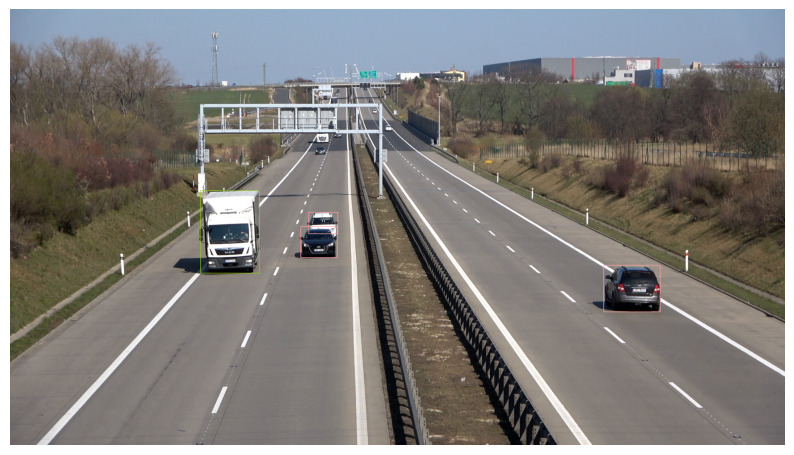

In [3]:
import cv2
import supervision as sv
from ultralytics import YOLO
from matplotlib import pyplot as plt

# 1. Load the pre-trained YOLOv8 model
print("Loading YOLOv8 model...")
model = YOLO('yolov8n.pt') # 'n' stands for nano (fastest version)

# 2. Grab just the first frame of our video
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

# 3. Run the AI on that frame
results = model(frame)[0]

# 4. Use supervision to draw the boxes nicely
detections = sv.Detections.from_ultralytics(results)
box_annotator = sv.BoxAnnotator()
annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections)

# 5. Display the image
# Convert BGR (OpenCV format) to RGB (Matplotlib format)
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(annotated_frame)
plt.axis('off')
plt.show()

In [5]:
import cv2
import supervision as sv
from ultralytics import YOLO

# 1. Setup Models and Paths
print("Initializing YOLOv8 and ByteTrack...")
model = YOLO('yolov8n.pt')
SOURCE_VIDEO_PATH = "traffic.mp4"
TARGET_VIDEO_PATH = "traffic_tracked.mp4"

# 2. Get Video Info & Initialize the Tracker
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

tracker = sv.ByteTrack()

# FIX: Changed BoundingBoxAnnotator to BoxAnnotator to match the newest version
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1)

print("Processing video... (This might take a minute or two)")

# 3. Process every frame and save to a new video
with sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info) as sink:
    for frame in generator:
        # Step A: YOLO detects the objects (verbose=False hides the spammy logs)
        results = model(frame, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)

        # Step B: ByteTrack assigns unique IDs to the detections
        detections = tracker.update_with_detections(detections)

        # Step C: Create labels (e.g., "#5 car")
        labels = [
            f"#{tracker_id} {model.names[class_id]}"
            for class_id, tracker_id
            in zip(detections.class_id, detections.tracker_id)
        ]

        # Step D: Draw the boxes and labels onto the frame
        annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        # Step E: Write the finished frame to our new video file
        sink.write_frame(annotated_frame)

print(f"✅ Tracking complete! Your new video is saved as: {TARGET_VIDEO_PATH}")

Initializing YOLOv8 and ByteTrack...
Processing video... (This might take a minute or two)
✅ Tracking complete! Your new video is saved as: traffic_tracked.mp4


In [6]:
import cv2
import supervision as sv
from ultralytics import YOLO

# 1. Setup Models and Paths
print("Initializing YOLOv8, ByteTrack, and Spatial Analytics...")
model = YOLO('yolov8n.pt')
SOURCE_VIDEO_PATH = "traffic.mp4"
TARGET_VIDEO_PATH = "traffic_counted.mp4"

# 2. Get Video Info & Initialize tools
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_thickness=1)

# --- PHASE 3 ADDITION: THE COUNTING LINE ---
# We dynamically draw a virtual line straight across the exact center of the video
start_point = sv.Point(0, video_info.height // 2)
end_point = sv.Point(video_info.width, video_info.height // 2)

line_zone = sv.LineZone(start=start_point, end=end_point)
line_zone_annotator = sv.LineZoneAnnotator(thickness=2, text_thickness=2, text_scale=1)
# -------------------------------------------

print("Processing video and counting vehicles... ")

with sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info) as sink:
    for frame in generator:
        # Detect and Track
        results = model(frame, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)
        detections = tracker.update_with_detections(detections)

        # --- PHASE 3 ADDITION: UPDATE COUNTERS ---
        # Trigger the line zone to check if any tracked objects crossed the line
        line_zone.trigger(detections=detections)
        # -----------------------------------------

        # Labels and boxes
        labels = [
            f"#{tracker_id} {model.names[class_id]}"
            for class_id, tracker_id
            in zip(detections.class_id, detections.tracker_id)
        ]
        annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)

        # --- PHASE 3 ADDITION: DRAW THE LINE ---
        # Draw the virtual tripwire and the live "In / Out" counts on the frame
        annotated_frame = line_zone_annotator.annotate(annotated_frame, line_counter=line_zone)
        # ---------------------------------------

        sink.write_frame(annotated_frame)

print(f"✅ Analytics complete! Your final video is saved as: {TARGET_VIDEO_PATH}")
print(f"📊 Final Traffic Count - In: {line_zone.in_count}, Out: {line_zone.out_count}")

Initializing YOLOv8, ByteTrack, and Spatial Analytics...
Processing video and counting vehicles... 
✅ Analytics complete! Your final video is saved as: traffic_counted.mp4
📊 Final Traffic Count - In: 3, Out: 5


In [7]:
import cv2
import os
import urllib.request
import numpy as np
import supervision as sv
from ultralytics import YOLO

# 1. Download a fresh test video
video_url = "https://media.roboflow.com/supervision/video-examples/vehicles.mp4"
video_path = "traffic_intersection.mp4"
if not os.path.exists(video_path):
    print("Downloading test video...")
    urllib.request.urlretrieve(video_url, video_path)

# 2. Setup the AI & Output Folder
print("Initializing YOLOv8 and Smart City Engine...")
model = YOLO('yolov8n.pt')
tracker = sv.ByteTrack()

# Create a folder to store the images of the cars that break the law
output_dir = "violations"
os.makedirs(output_dir, exist_ok=True)

# 3. Define our Rules
TRAFFIC_LIGHT = "RED" # We are simulating that the light is currently red
video_info = sv.VideoInfo.from_video_path(video_path)
generator = sv.get_video_frames_generator(video_path)

# Draw the "Stop Line"
start_point = sv.Point(0, video_info.height // 2)
end_point = sv.Point(video_info.width, video_info.height // 2)
line_zone = sv.LineZone(start=start_point, end=end_point)

print("Monitoring traffic for red light violations...")

# 4. The Processing Loop
for frame_count, frame in enumerate(generator):

    # Run Detection & Tracking
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)

    # Check if anyone crossed the stop line
    crossed_in, crossed_out = line_zone.trigger(detections=detections)

    # Evaluate Violations
    for i in range(len(detections)):
        # If the car crossed the line AND the light is red
        if crossed_in[i] and TRAFFIC_LIGHT == "RED":
            tracker_id = detections.tracker_id[i]
            bbox = detections.xyxy[i] # Get the bounding box coordinates [x1, y1, x2, y2]

            # Extract the coordinates as integers
            x1, y1, x2, y2 = [int(v) for v in bbox]

            # --- THE MAGIC: CROP THE IMAGE ---
            # We use standard Python array slicing to crop the exact car out of the 4K frame
            cropped_car = frame[y1:y2, x1:x2]

            # Save the evidence!
            if cropped_car.size > 0:
                filename = f"{output_dir}/violator_ID{tracker_id}_frame{frame_count}.jpg"
                cv2.imwrite(filename, cropped_car)
                print(f"🚨 VIOLATION DETECTED! Car #{tracker_id} ran the red light. Evidence saved.")

print("\n✅ Patrol complete! Check your 'violations' folder.")

Initializing YOLOv8 and Smart City Engine...
Monitoring traffic for red light violations...
🚨 VIOLATION DETECTED! Car #1 ran the red light. Evidence saved.
🚨 VIOLATION DETECTED! Car #9 ran the red light. Evidence saved.
🚨 VIOLATION DETECTED! Car #23 ran the red light. Evidence saved.

✅ Patrol complete! Check your 'violations' folder.


In [8]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 31.5 MB/s eta 0:00:00


Initializing EasyOCR Engine...


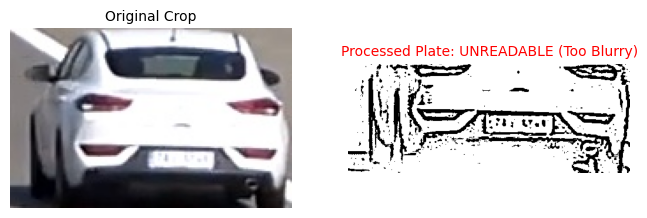

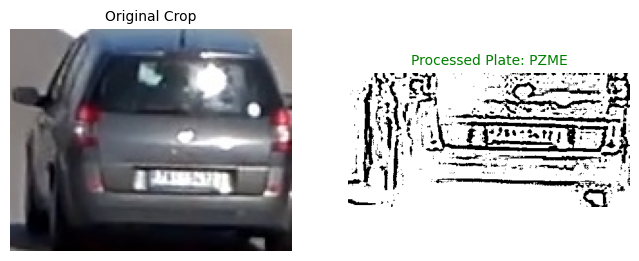

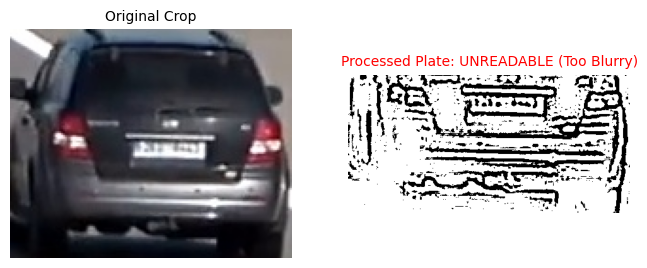

✅ Enhanced OCR Pipeline Complete!


In [10]:
import os
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt

print("Initializing EasyOCR Engine...")
reader = easyocr.Reader(['en'], gpu=True)
violation_dir = "violations"
image_files = [f for f in os.listdir(violation_dir) if f.endswith('.jpg')]

for img_file in image_files:
    img_path = os.path.join(violation_dir, img_file)
    img = cv2.imread(img_path)

    # --- ENTERPRISE PREPROCESSING TRICKS ---
    # 1. Crop to the bottom 60% of the car (where the plate is)
    h, w, _ = img.shape
    bottom_half = img[int(h*0.4):h, :]

    # 2. Convert to Grayscale
    gray = cv2.cvtColor(bottom_half, cv2.COLOR_BGR2GRAY)

    # 3. Resize the image to make it 3x bigger (helps OCR read tiny pixels)
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # 4. Apply high contrast (Thresholding) to make the text pop
    # We use adaptive thresholding to handle shadows
    processed_img = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    # ---------------------------------------

    # Run OCR on the highly processed, zoomed-in image
    results = reader.readtext(processed_img)

    extracted_text = []
    for (bbox, text, prob) in results:
        # Lowered confidence threshold since the video is a bit blurry
        if prob > 0.10 and len(text) > 3:
            extracted_text.append(text.upper())

    plate_text = " | ".join(extracted_text) if extracted_text else "UNREADABLE (Too Blurry)"

    # Display the result alongside our newly processed image
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Crop", fontsize=10)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(processed_img, cmap='gray')
    plt.title(f"Processed Plate: {plate_text}", fontsize=10, color='red' if "UNREADABLE" in plate_text else 'green')
    plt.axis('off')

    plt.show()

print("✅ Enhanced OCR Pipeline Complete!")

In [22]:
import os
import cv2
import easyocr
import numpy as np
import gradio as gr
import supervision as sv
from ultralytics import YOLO

print("Loading Models for Dashboard...")
model = YOLO('yolov8n.pt')
reader = easyocr.Reader(['en'], gpu=True)

# --- NEW: COCO Class Mapping ---
# 1: Bicycle, 2: Car, 3: Motorcycle, 5: Bus, 7: Truck
CLASS_MAP = {
    1: "2-Wheeler",
    2: "4-Wheeler",
    3: "2-Wheeler",
    5: "Heavy Vehicle",
    7: "Heavy Vehicle"
}

def process_traffic(video_file):
    try:
        if video_file is None:
            return None, []

        tracker = sv.ByteTrack()
        video_info = sv.VideoInfo.from_video_path(video_file)
        generator = sv.get_video_frames_generator(video_file)

        line_y = int(video_info.height * 0.75)
        start_point = sv.Point(0, line_y)
        end_point = sv.Point(video_info.width, line_y)
        line_zone = sv.LineZone(start=start_point, end=end_point)

        box_annotator = sv.BoxAnnotator(thickness=2)
        # Made text slightly smaller to fit the new data
        label_annotator = sv.LabelAnnotator(text_scale=0.4, text_thickness=1)
        line_annotator = sv.LineZoneAnnotator(thickness=2, text_thickness=2, text_scale=1)

        output_video_path = "enforcement_output.mp4"
        violations_gallery = []
        ticketed_cars = set()

        # --- NEW: Speed Tracking Memory ---
        vehicle_history = {}
        pixel_to_kmh = 0.8 # Arbitrary scale factor to convert pixels/sec to km/h

        frame_count = 0

        # --- FIX 1: Dynamically calculate exactly 9 seconds based on video FPS ---
        max_frames = int(video_info.fps * 9)

        with sv.VideoSink(output_video_path, video_info=video_info) as sink:
            for frame in generator:
                if frame_count >= max_frames:
                    break
                frame_count += 1

                results = model(frame, verbose=False)[0]
                detections = sv.Detections.from_ultralytics(results)
                detections = tracker.update_with_detections(detections)

                crossed_in, crossed_out = line_zone.trigger(detections=detections)

                # We will build custom labels for every box
                custom_labels = []

                for i in range(len(detections)):
                    tracker_id = detections.tracker_id[i]
                    class_id = detections.class_id[i]
                    bbox = detections.xyxy[i]

                    # --- FIX 2: Vehicle Type ---
                    v_type = CLASS_MAP.get(class_id, "Vehicle")

                    # --- FIX 3: Speed Calculation ---
                    # Calculate the center point (Y-axis) of the vehicle
                    centroid_y = (bbox[1] + bbox[3]) / 2
                    speed_kmh = 0

                    if tracker_id in vehicle_history:
                        prev_y, prev_frame = vehicle_history[tracker_id]
                        frames_passed = frame_count - prev_frame

                        if frames_passed > 0:
                            # Distance / Time * Scale Factor
                            pixel_distance = abs(centroid_y - prev_y)
                            speed_kmh = int((pixel_distance / frames_passed) * video_info.fps * pixel_to_kmh)

                    # Update history every 3 frames to smooth out speed calculations
                    if frame_count % 3 == 0 or tracker_id not in vehicle_history:
                        vehicle_history[tracker_id] = (centroid_y, frame_count)

                    # Add our new dynamic label
                    custom_labels.append(f"#{tracker_id} {v_type} | {speed_kmh}km/h")

                    # --- Red Light Logic ---
                    if (crossed_in[i] or crossed_out[i]) and tracker_id not in ticketed_cars:
                        ticketed_cars.add(tracker_id)

                        x1, y1, x2, y2 = max(0, int(bbox[0]) - 5), max(0, int(bbox[1]) - 5), max(0, int(bbox[2]) + 5), max(0, int(bbox[3]) + 5)
                        cropped_car = frame[y1:y2, x1:x2]

                        if cropped_car.shape[0] > 20 and cropped_car.shape[1] > 20:
                            try:
                                h, w, _ = cropped_car.shape
                                bottom_half = cropped_car[int(h*0.4):h, :]
                                gray = cv2.cvtColor(bottom_half, cv2.COLOR_BGR2GRAY)
                                gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
                                processed_img = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

                                ocr_results = reader.readtext(processed_img)
                                extracted_text = [text.upper() for (bbox, text, prob) in ocr_results if prob > 0.10 and len(text) > 3]
                                plate_text = " | ".join(extracted_text) if extracted_text else "UNREADABLE"

                                rgb_crop = cv2.cvtColor(cropped_car, cv2.COLOR_BGR2RGB)
                                caption = f"ID #{tracker_id} | {v_type} | {speed_kmh}km/h | Plate: {plate_text}"
                                violations_gallery.append((rgb_crop, caption))
                            except Exception as e:
                                print(f"OCR Skipped: {e}")

                # Draw the boxes and apply our new custom labels
                annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections)
                annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=custom_labels)
                annotated_frame = line_annotator.annotate(annotated_frame, line_counter=line_zone)
                sink.write_frame(annotated_frame)

        return output_video_path, violations_gallery

    except Exception as fatal_error:
        raise gr.Error(f"System Crash: {str(fatal_error)}")

with gr.Blocks(theme=gr.themes.Monochrome()) as app:
    gr.Markdown("# 🚦 Smart City Automated Traffic Enforcement")
    gr.Markdown("Upload a traffic feed. The AI will track vehicles, estimate speeds, classify vehicle types, detect violations, and extract license plates. *(Demo Mode: First 9 Seconds).*")

    with gr.Row():
        with gr.Column(scale=1):
            video_input = gr.Video(label="Upload Traffic Camera Feed")
            process_btn = gr.Button("🚨 Run Enforcement AI", variant="primary")

        with gr.Column(scale=1):
            video_output = gr.Video(label="Live Tracking Feed")

    gr.Markdown("### 🚔 Violation Log & OCR Evidence")
    gallery_output = gr.Gallery(label="Captured Offenders", columns=4, rows=1, object_fit="contain", height="auto")

    process_btn.click(
        fn=process_traffic,
        inputs=[video_input],
        outputs=[video_output, gallery_output]
    )

app.launch(debug=True)

Loading Models for Dashboard...


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://63057e93d55aaf1024.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7866 <> https://63057e93d55aaf1024.gradio.live
